Calculate binding energy and escape velocity on a pair of stars, with monte carlo error propigation.

4. binding energy:
    - luminosity from Gaia or using distance and apparent magnitude
    - masses from luminosity using (Duric, 2004)
    - binding energy from masses using (Letchford et al., 2022)
5. System escape velocity using the method of Bonifacio (Bonifacio et al., 2020)


In [34]:
# first provide the gaia source_id values for the primary and secondary

# AG 342 AB
#gaia_id_pri = 3996306127913903232
#gaia_id_sec = 3996306127914172928

# STF 1645 AB
gaia_id_pri = 1541667932396172800
gaia_id_sec = 1541667932396172416

# STF 648 AB
#gaia_id_pri = 181312735893067008
#gaia_id_sec = 181318611408327552

# STF 518 BC
#gaia_id_pri=3195919254111315712
#gaia_id_sec=3195919254111314816

# DUN 5
#gaia_id_pri=4911306239828325632
#gaia_id_sec=4911306239828325760

In [35]:

# now import the data

import numpy as np
import astropy.units as u
from astroquery.gaia import Gaia
from astropy.table import Table
from astropy.table import vstack, unique


query_base = """
SELECT
    TOP 10
    *
    FROM gaiadr3.gaia_source AS g
    JOIN gaiadr3.astrophysical_parameters AS ap ON g.source_id = ap.source_id

    WHERE g.source_id IN ({id_pri}, {id_sec})
"""

query=query_base.format(id_pri=gaia_id_pri, id_sec=gaia_id_sec)
print(query)

job = Gaia.launch_job(query)
results = job.get_results()

results_t = Table()
results_t = vstack([results_t, results])


SELECT
    TOP 10
    *
    FROM gaiadr3.gaia_source AS g
    JOIN gaiadr3.astrophysical_parameters AS ap ON g.source_id = ap.source_id

    WHERE g.source_id IN (1541667932396172800, 1541667932396172416)



In [36]:
# retrieve the primary and secondary rows
results_t.add_index('source_id')
pri=results_t.loc[gaia_id_pri]
sec=results_t.loc[gaia_id_sec]
display(results_t)


solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,astrometric_n_obs_al,astrometric_n_obs_ac,astrometric_n_good_obs_al,astrometric_n_bad_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,astrometric_primary_flag,nu_eff_used_in_astrometry,pseudocolour,pseudocolour_error,ra_pseudocolour_corr,dec_pseudocolour_corr,parallax_pseudocolour_corr,pmra_pseudocolour_corr,pmdec_pseudocolour_corr,astrometric_matched_transits,visibility_periods_used,astrometric_sigma5d_max,matched_transits,new_matched_transits,matched_transits_removed,ipd_gof_harmonic_amplitude,ipd_gof_harmonic_phase,ipd_frac_multi_peak,ipd_frac_odd_win,ruwe,scan_direction_strength_k1,scan_direction_strength_k2,scan_direction_strength_k3,scan_direction_strength_k4,scan_direction_mean_k1,scan_direction_mean_k2,scan_direction_mean_k3,scan_direction_mean_k4,duplicated_source,phot_g_n_obs,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_n_obs,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_n_obs,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,phot_bp_n_contaminated_transits,phot_bp_n_blended_transits,phot_rp_n_contaminated_transits,phot_rp_n_blended_transits,phot_proc_mode,bp_rp,bp_g,g_rp,radial_velocity,radial_velocity_error,rv_method_used,rv_nb_transits,rv_nb_deblended_transits,rv_visibility_periods_used,rv_expected_sig_to_noise,rv_renormalised_gof,rv_chisq_pvalue,rv_time_duration,rv_amplitude_robust,rv_template_teff,rv_template_logg,rv_template_fe_h,rv_atm_param_origin,vbroad,vbroad_error,vbroad_nb_transits,grvs_mag,grvs_mag_error,grvs_mag_nb_transits,rvs_spec_sig_to_noise,phot_variable_flag,l,b,ecl_lon,ecl_lat,in_qso_candidates,in_galaxy_candidates,non_single_star,has_xp_continuous,has_xp_sampled,has_rvs,has_epoch_photometry,has_epoch_rv,has_mcmc_gspphot,has_mcmc_msc,in_andromeda_survey,classprob_dsc_combmod_quasar,classprob_dsc_combmod_galaxy,classprob_dsc_combmod_star,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot,solution_id2,source_id2,classprob_dsc_combmod_quasar2,classprob_dsc_combmod_galaxy2,classprob_dsc_combmod_star2,classprob_dsc_combmod_whitedwarf,classprob_dsc_combmod_binarystar,classprob_dsc_specmod_quasar,classprob_dsc_specmod_galaxy,classprob_dsc_specmod_star,classprob_dsc_specmod_whitedwarf,classprob_dsc_specmod_binarystar,classprob_dsc_allosmod_quasar,classprob_dsc_allosmod_galaxy,classprob_dsc_allosmod_star,teff_gspphot2,teff_gspphot_lower2,teff_gspphot_upper2,logg_gspphot2,logg_gspphot_lower2,logg_gspphot_upper2,mh_gspphot2,mh_gspphot_lower2,mh_gspphot_upper2,distance_gspphot2,distance_gspphot_lower2,distance_gspphot_upper2,azero_gspphot2,azero_gspphot_lower2,azero_gspphot_upper2,ag_gspphot2,ag_gspphot_lower2,ag_gspphot_upper2,abp_gspphot,abp_gspphot_lower,abp_gspphot_upper,arp_gspphot,arp_gspphot_lower,arp_gspphot_upper,ebpminrp_gspphot2,ebpminrp_gspphot_lower2,ebpminrp_gspphot_upper2,mg_gspphot,mg_gspphot_lower,mg_gspphot_upper,radius_gspphot,radius_gspphot_lower,radius_gspphot_upper,logposterior_gspphot,mcmcaccept_gspphot,libname_gspphot2,teff_gspspec,teff_gspspec_lower,teff_gspspec_upper,logg_gspspec,logg_gspspec_lower,logg_gspspec_upper,mh_gspspec,mh_gspspec_lower,mh_gspspec_upper,alphafe_gspspec,alphafe_gspspec_lower,alph

Monte carlo simulation to estimate probability of bound states using Gaia data.


Each stellar parameter has a distribution described by the published mean and error values in Gaia DR3.
Our strategy is to sample those parameter distributions repeatedly to create a sample set of primary / secondary stellar pairs. We then compute the relative velocities, and spatial separation for each pair, which combined with estimated stellar masses produce binding energy and escape velocity values. Each sample pair then can be determined to be either bound or unbound, and simple counting of the entire population allows an estimate of the probability that the target stars are bound.


e_binding median 0.3218663839746315 km2 solMass / s2
e_binding smad 0.0614352083646361 km2 solMass / s2
vel_escape median 0.4653248943229885 km / s
vel_escape smad 0.16235650248652012 km / s
vel_escape-velrel median -0.7630704332466296 km / s
vel_escape-velrel smad 0.19440433136652638 km / s
n_bound_escape 68497
n_bound_binding 68497
prob bound escape 0.068497
prob bound binding 0.068497


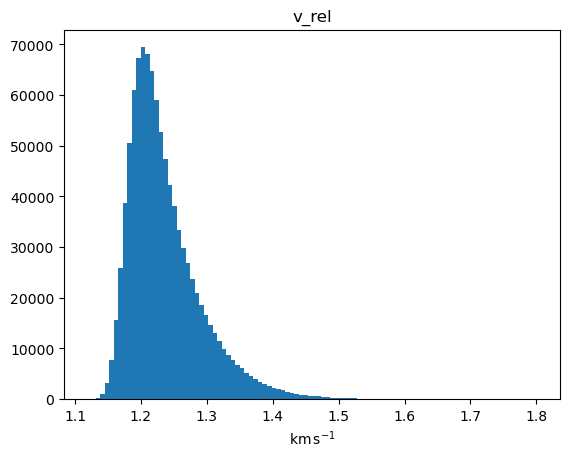

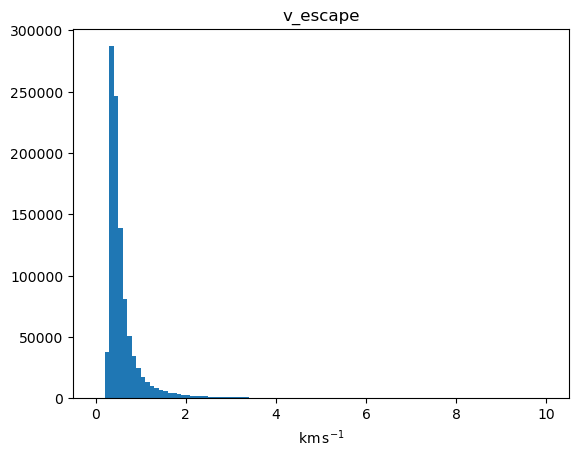

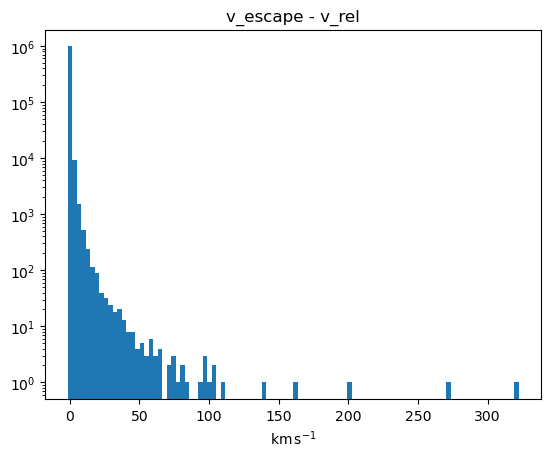

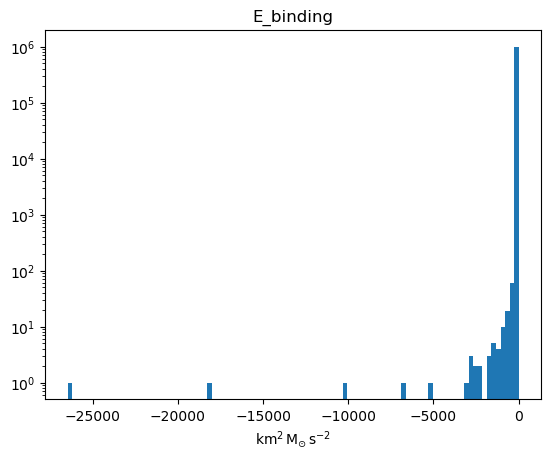

In [37]:
# distribution of stars and sampling

import astropy.constants as const
from astropy.coordinates import SkyCoord, Distance

from astropy import uncertainty as unc

#number of samples
n = 1000000

#rng = np.random.default_rng(12345)  # ensures reproducible example numbers

# extract the star information from a row of gaia data
# sample the distribution of each parameter and return a sample set
# !!! eventually can calculate mass from available data if mass_flame is not specified
def star_sample(row):
    ra = unc.normal(row['ra']*u.deg, std=row['ra_error']*u.deg, n_samples=n)
    dec = unc.normal(row['dec']*u.deg, std=row['dec_error']*u.deg, n_samples=n)
    pmra = unc.normal(row['pmra']*u.mas/u.year, std=row['pmra_error']*u.mas/u.year, n_samples=n)
    pmdec = unc.normal(row['pmdec']*u.mas/u.year, std=row['pmdec_error']*u.mas/u.year, n_samples=n)
    parallax = unc.normal(row['parallax']*u.mas, std=row['parallax_error']*u.mas, n_samples=n)
    velrad = unc.normal(row['radial_velocity']*u.km/u.s, std=row['radial_velocity_error']*u.km/u.s, n_samples=n)
    #!!! is mass uniformly distributed?
    mass = unc.uniform(lower=row['mass_flame_lower']*u.M_sun, upper=row['mass_flame_upper']*u.M_sun, n_samples=n)
    #mass = row['mass_flame']*u.M_sun
    return {'ra':ra, 'dec':dec, 'pmra': pmra, 'pmdec':pmdec, 'parallax':parallax, 'velrad':velrad, 'mass':mass}

#    return SkyCoord(ra=ra, dec=dec,  pm_ra_cosdec=pmra, pm_dec=pmdec, radial_velocity=radial_velocity, frame='icrs')

# converts proper motion to km/s velocity
def pm_mas_to_kps(pm, parallax):
  return 4.74*(u.km/u.s*u.year)*pm/parallax

# returns 3d velocity of star
def velocity(pmra, pmdec, parallax, velrad):
  velra=pm_mas_to_kps(pmra, parallax)
  veldec=pm_mas_to_kps(pmdec, parallax)
  return (velra, veldec, velrad)

# returns the magnitude of a 3-vector
def mag(v):
    x,y,z=v
    return np.sqrt(x**2+y**2+z**2)

# returns the dot product of two 3-vectors
def dot(v1, v2):
   x1,y1,z1=v1
   x2,y2,z2=v2
   return (x1*x2 + y1*y2 + z1*z2)

# returns the relative angle between two 3-vectors
def theta(v1,v2):
    return np.arccos(dot(v1,v2)/(mag(v1)*mag(v2)))

def diff(v1,v2):
  x1,y1,z1=v1
  x2,y2,z2=v2
  return (x1-x2, y1-y2, z1-z2)

# returns the  separation angle between the two spherical coordinates
def sep_haversine(ra1, dec1, ra2, dec2):
   angle = (np.arcsin(np.sqrt( np.sin((dec2-dec1)/2)**2 + np.cos(dec1)*np.cos(dec2)*np.sin((ra2-ra1)/2)**2 ))*2)
   return angle

# return the distance between two stars with the given distances and angular separation
def distance_3d(dist1, dist2, sep):
   radial = dist1-dist2
   #need to reset with astype for some reason, otherwise next operation will error
   projected = ((sep) * (dist1-dist2)/2 / u.rad).astype(np.float64)
   return np.sqrt(np.square(projected)+np.square(radial))

# display stats for the given distribution
def display_stats(name, dist):
   d=dist.distribution
   print(name, "median", np.median(d))# .pdf_mean())
   print(name, "smad", dist.pdf_smad())

# return the distance for a given parallax
def distance(parallax):
   return 1000*u.mas*u.pc/parallax

# create sample populations for the primary and secondary stars
# and calculate some basic velocity, distance parameters
sample_pri = star_sample(pri)
velvec_pri = velocity(sample_pri['pmra'], sample_pri['pmdec'], sample_pri['parallax'], sample_pri['velrad'])
velmag_pri = mag(velvec_pri)
distance_pri = distance(sample_pri['parallax'])

sample_sec = star_sample(sec)
velvec_sec = velocity(sample_sec['pmra'], sample_sec['pmdec'], sample_sec['parallax'], sample_sec['velrad'])
velmag_sec = mag(velvec_sec)
distance_sec = distance(sample_sec['parallax'])

# calculate relative velocity, angular separation and space distance of stars
vel_rel = mag(diff(velvec_pri, velvec_sec))
sep = sep_haversine(sample_pri['ra'], sample_pri['dec'], sample_sec['ra'], sample_sec['dec'])
distance_space = distance_3d(distance_pri, distance_sec, sep)

# display statistics of calculated values
#display_stats("vel_rel", vel_rel)
#display_stats("sep", sep)
#display_stats("distance_space", distance_space)

mass_pri = sample_pri['mass']
mass_sec = sample_sec['mass']
#display_stats('1/distance_space', 1/distance_space)
# calculate binding energy
e_binding_lhs = 1/2 * mass_pri*mass_sec/(mass_pri+mass_sec) * vel_rel**2 
# !!! why is the std error for this term so high?
e_binding_rhs = (- const.G*mass_pri*mass_sec/distance_space).to(u.km**2*u.M_sun/u.s**2)

e_binding=e_binding_lhs+e_binding_rhs

#display_stats('e_binding_lhs', e_binding_lhs)
#display_stats('e_binding_rhs', e_binding_rhs)
display_stats('e_binding', e_binding)

# calculate escape velocity
mass_total = mass_pri+mass_sec
vel_escape = np.sqrt(2*const.G*mass_total/distance_space).to(u.km/u.s)

display_stats("vel_escape", vel_escape)
display_stats("vel_escape-velrel", vel_escape-vel_rel)

# estimate probability of bound states
n_bound_escape = np.count_nonzero(((vel_escape-vel_rel) > 0).distribution)
n_bound_binding = np.count_nonzero((e_binding <= 0).distribution)

print('n_bound_escape', n_bound_escape)
print('n_bound_binding', n_bound_binding)
print('prob bound escape', n_bound_escape/n)
print('prob bound binding', n_bound_binding/n)


from matplotlib import pyplot as plt
from astropy.visualization import quantity_support

with quantity_support():
    fig, ax = plt.subplots()
    ax.set_title("v_rel")
    ax.hist((vel_rel).distribution, bins=100, log=False)

with quantity_support():
    fig, ax = plt.subplots()
    ax.set_title("v_escape")
    ax.hist((vel_escape).distribution, bins=100, range=(0, 10), log=False)

with quantity_support():
    fig, ax = plt.subplots()
    ax.set_title("v_escape - v_rel")
    ax.hist((vel_escape-vel_rel).distribution, bins=100, log=True)

with quantity_support():
    fig, ax = plt.subplots()
    ax.set_title("E_binding")
    ax.hist((e_binding).distribution, bins=100, log=True)





In [14]:
print(1/0.004)
print(1/0.014)

250.0
71.42857142857143


# DUN 5

e_binding median 0.7678801452058164 km2 solMass / s2
e_binding smad 0.22077551218924207 km2 solMass / s2
vel_escape median 1.4039355124573376 km / s
vel_escape smad 0.3124241209772965 km / s
vel_escape-velrel median -1.0072544932988046 km / s
vel_escape-velrel smad 0.3416055796139444 km / s
n_bound_escape 74376
n_bound_binding 74376
prob bound escape 0.074376
prob bound binding 0.074376


# STF 1645

e_binding median 0.3218177807948811 km2 solMass / s2
e_binding smad 0.06131369636882998 km2 solMass / s2
vel_escape median 0.46522052084958254 km / s
vel_escape smad 0.16215721966801427 km / s
vel_escape-velrel median -0.7631117429435166 km / s
vel_escape-velrel smad 0.19438267427208483 km / s
n_bound_escape 68742
n_bound_binding 68742
prob bound escape 0.068742
prob bound binding 0.068742
